# Notebook 07 — Heterogeneous Treatment Effects (HTE)

**Question**: Does chemotherapy benefit all patients equally — or only certain subgroups?

**Figures saved**: `results/figures/07_*.png`

---
### Concept at a Glance

```
NB02–06 estimated the Average Treatment Effect (ATE) — one number for everyone.
But the truth may look like this:

  Stage I   patient: CATE = +2 months   (small benefit)
  Stage II  patient: CATE = +5 months
  Stage III patient: CATE = +9 months
  Stage IV  patient: CATE = +14 months  (large benefit)

  ATE = average of all the above ≠ any individual's true effect
```

**Key concepts:**
- **CATE** — Conditional Average Treatment Effect: `E[Y(1)-Y(0) | X=x]`, the treatment effect as a function of patient characteristics
- **Effect modifier** — a variable that *changes* the treatment effect (different from a confounder, which *biases* it)
- **Interaction term** — regression test: `Chemo × Stage` coefficient ≠ 0 means Stage modifies the chemo effect
- **Causal Forest** — machine learning method that estimates per-patient CATE non-parametrically

**Clinical relevance:** If Stage IV patients benefit 7× more than Stage I patients, precision treatment targeting
high-benefit subgroups improves outcomes and reduces unnecessary toxicity in low-benefit patients.

> Deep dive: `docs/concepts.md` | Figures: `docs/figures_guide.md`
---

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from econml.dml import CausalForestDML

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 130, 'font.size': 10})

PARQUET  = os.path.join('..', 'data', 'processed', 'analysis_dataset.parquet')
FIG_DIR  = os.path.join('..', 'results', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_parquet(PARQUET)
print(f'Loaded {len(df):,} patients, {df["CANCER_TYPE_ABBR"].nunique()} cancer types')
print(f'Chemo rate: {df["CHEMO"].mean():.1%}  |  Event rate: {df["OS_EVENT"].mean():.1%}')

STAGE_LABELS = {1: 'Stage I', 2: 'Stage II', 3: 'Stage III', 4: 'Stage IV'}
STAGE_COLORS = {1: '#4CAF50', 2: '#FFC107', 3: '#FF9800', 4: '#F44336'}

/opt/anaconda3/envs/multiomics-demo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 6,568 patients, 19 cancer types
Chemo rate: 43.8%  |  Event rate: 30.4%


## 1. Visual HTE Check: Stratified KM Curves

The simplest way to detect HTE: plot KM curves for chemo vs no-chemo *within each stage*.
If the gap between curves varies across stages, stage is an effect modifier.

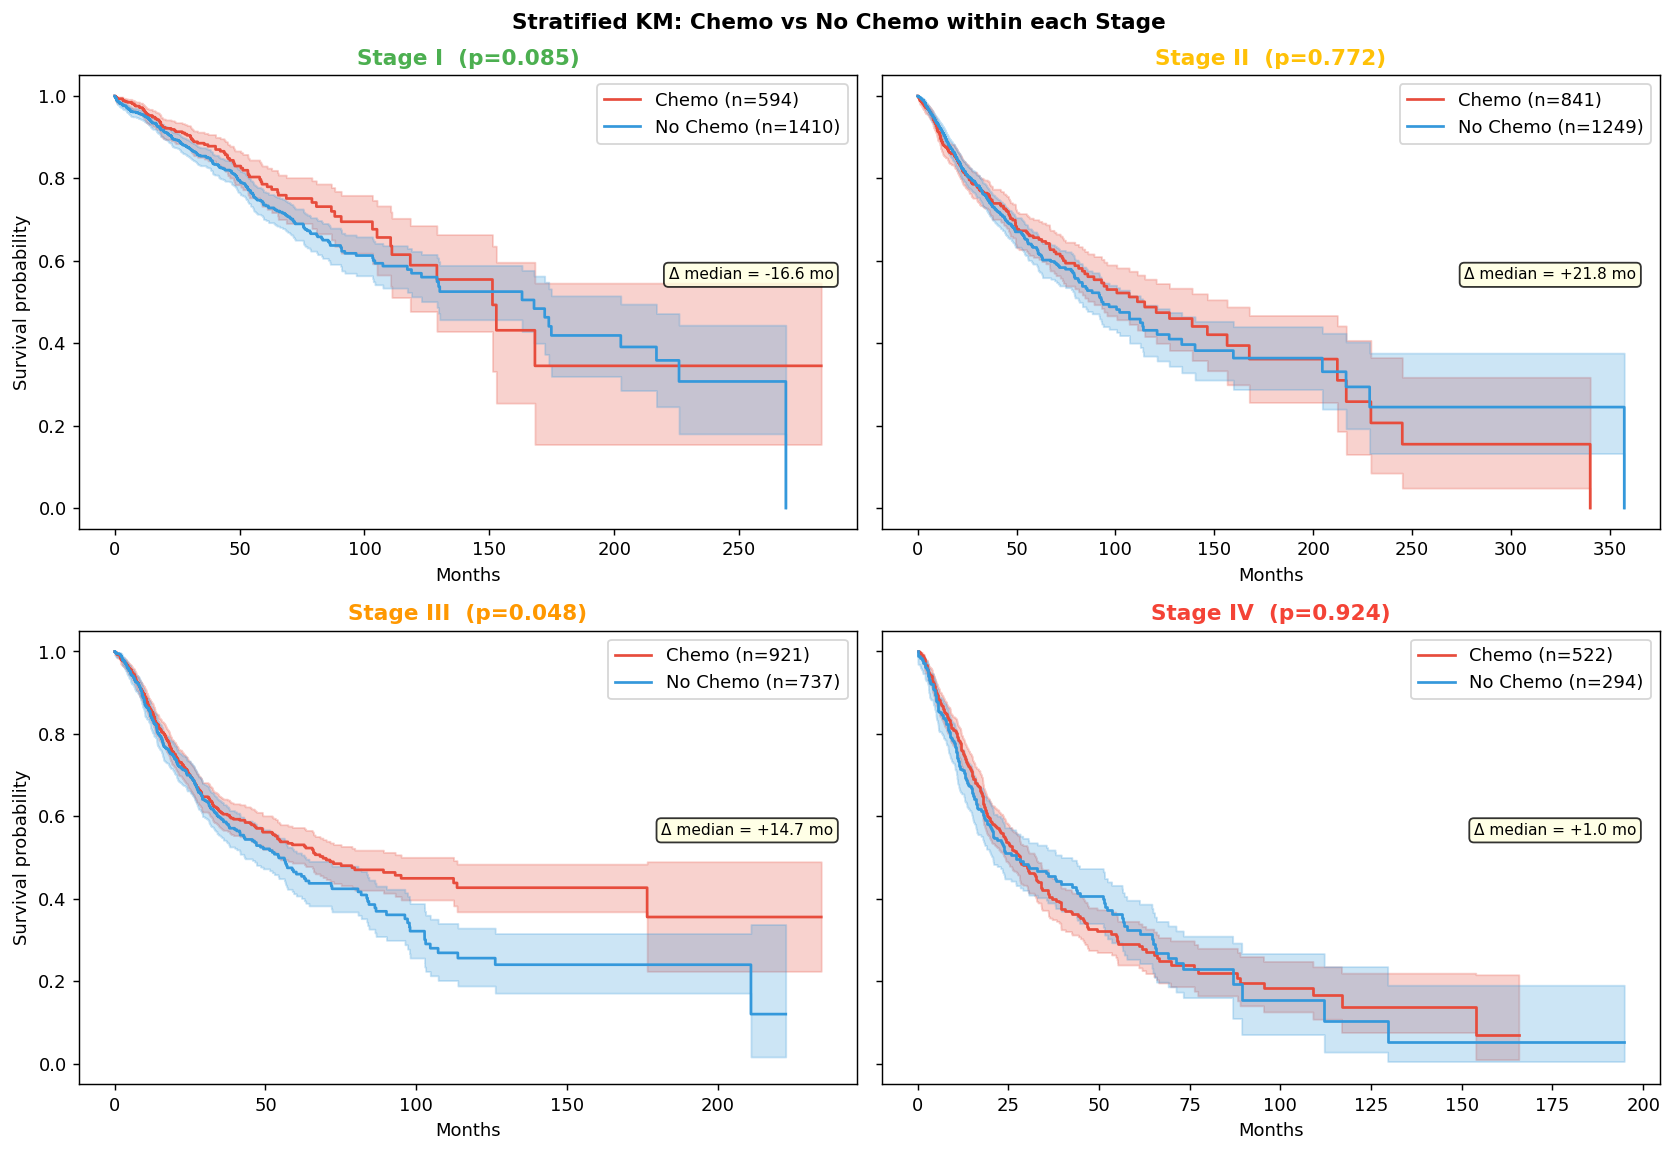

Median survival difference (chemo - no chemo) by stage:
  Stage I: -16.6 months
  Stage II: +21.8 months
  Stage III: +14.7 months
  Stage IV: +1.0 months


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
kmf = KaplanMeierFitter()

ate_by_stage = {}
for ax, stage in zip(axes.flat, [1, 2, 3, 4]):
    sub = df[df['STAGE'] == stage]
    t1  = sub[sub['CHEMO'] == 1]
    t0  = sub[sub['CHEMO'] == 0]

    kmf.fit(t1['OS_MONTHS'], t1['OS_EVENT'], label=f'Chemo (n={len(t1)})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color='#E74C3C')
    med1 = kmf.median_survival_time_

    kmf.fit(t0['OS_MONTHS'], t0['OS_EVENT'], label=f'No Chemo (n={len(t0)})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color='#3498DB')
    med0 = kmf.median_survival_time_

    lr = logrank_test(t1['OS_MONTHS'], t0['OS_MONTHS'], t1['OS_EVENT'], t0['OS_EVENT'])
    delta = med1 - med0 if np.isfinite(med1) and np.isfinite(med0) else np.nan
    ate_by_stage[stage] = delta

    ax.set_title(f'{STAGE_LABELS[stage]}  (p={lr.p_value:.3f})', fontweight='bold',
                 color=STAGE_COLORS[stage])
    ax.set_xlabel('Months')
    ax.set_ylabel('Survival probability')
    if np.isfinite(delta):
        ax.text(0.97, 0.55, f'Δ median = {delta:+.1f} mo',
                transform=ax.transAxes, ha='right', fontsize=8.5,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Stratified KM: Chemo vs No Chemo within each Stage', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_km_by_stage.png'), bbox_inches='tight')
plt.show()

print('Median survival difference (chemo - no chemo) by stage:')
for s, d in ate_by_stage.items():
    print(f'  {STAGE_LABELS[s]}: {d:+.1f} months' if np.isfinite(d) else f'  {STAGE_LABELS[s]}: median not reached')

## 2. Formal HTE Test: Cox Interaction Term

An **interaction term** `Chemo × Stage` in the Cox model tests whether Stage *modifies* the chemo effect:

$$h(t|X) = h_0(t) \cdot \exp(\beta_1\text{Chemo} + \beta_2\text{Stage} + \beta_3\text{Age} + {\color{red}{\beta_4(\text{Chemo} \times \text{Stage})}} )$$

- $\beta_4 < 0$: chemo benefit *increases* with stage (Stage modifies effect positively)
- $\beta_4 = 0$: no interaction — effect is homogeneous across stages
- $\beta_4 > 0$: chemo benefit *decreases* with stage

In [3]:
cox_df = df[['OS_MONTHS', 'OS_EVENT', 'CHEMO', 'STAGE', 'AGE']].dropna()
cox_df = cox_df[cox_df['OS_MONTHS'] > 0].copy()
cox_df['CHEMO_X_STAGE'] = cox_df['CHEMO'] * cox_df['STAGE']

cph_main = CoxPHFitter()
cph_main.fit(cox_df[['OS_MONTHS', 'OS_EVENT', 'CHEMO', 'STAGE', 'AGE']],
             'OS_MONTHS', 'OS_EVENT')

cph_int = CoxPHFitter()
cph_int.fit(cox_df, 'OS_MONTHS', 'OS_EVENT')

print('=== Main Effects Only ===' )
cph_main.print_summary(decimals=3)
print('\n=== With Chemo × Stage Interaction ===')
cph_int.print_summary(decimals=3)

int_coef = cph_int.summary.loc['CHEMO_X_STAGE', 'coef']
int_p    = cph_int.summary.loc['CHEMO_X_STAGE', 'p']
int_hr   = np.exp(int_coef)
print(f'\nInteraction HR (Chemo×Stage): {int_hr:.3f}  p = {int_p:.4f}')
if int_p < 0.05:
    direction = 'increases' if int_coef < 0 else 'decreases'
    print(f'→ Significant interaction: chemo benefit {direction} with higher stage')
else:
    print('→ No significant interaction detected at α = 0.05')

=== Main Effects Only ===


<lifelines.CoxPHFitter: fitted with 6568 total observations, 4570 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
      baseline estimation = breslow
   number of observations = 6568
number of events observed = 1998
   partial log-likelihood = -15537.317
         time fit was run = 2026-05-01 11:21:16 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
CHEMO     -0.010     0.990     0.047          -0.101           0.081               0.904               1.085
STAGE      0.479     1.615     0.023           0.434           0.525               1.544               1.690
AGE        0.032     1.033     0.002           0.029           0.036               1.029               1.036

           cmp to      z       p  -log2(p)
covariate                                 
CHEMO       0.000 -0.212   0.832     0.265
STAGE       0.000 20.781 <0.0005   316.209
AGE         0.000 17.896 <0.0005   235.518
---
Concordance = 0.692
Partial AIC = 31080.634
log-likelihood ratio test = 868.038 on 3 df
-log2(p) of ll-ratio test = 621.600


=== With Chemo × Stage Interaction ===


<lifelines.CoxPHFitter: fitted with 6568 total observations, 4570 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
      baseline estimation = breslow
   number of observations = 6568
number of events observed = 1998
   partial log-likelihood = -15536.912
         time fit was run = 2026-05-01 11:21:17 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
CHEMO         -0.119     0.887     0.131          -0.376           0.137               0.687               1.146
STAGE          0.461     1.586     0.031           0.401           0.521               1.493               1.684
AGE            0.032     1.033     0.002           0.029           0.036               1.029               1.036
CHEMO_X_STAGE  0.042     1.042     0.046          -0.049           0.132               0.952               1.141

               cmp to      z       p  -log2(p)
covariate                                     
CHEMO           0.000 -0.914   0.361     1.472
STAGE           0.000 14.968 <0.0005   165.854
AGE             0.000 17.887 <0.0005   235.289
CHEMO_X_STAGE   0.000  0.899   0.369     1.440
---
Concordance = 0.692
Partial AIC = 31081.824
log-likelihood ratio test = 868.848 on 4 df
-log2(p) of ll-ratio test = 617.975


Interaction HR (Chemo×Stage): 1.042  p = 0.3686
→ No significant interaction detected at α = 0.05


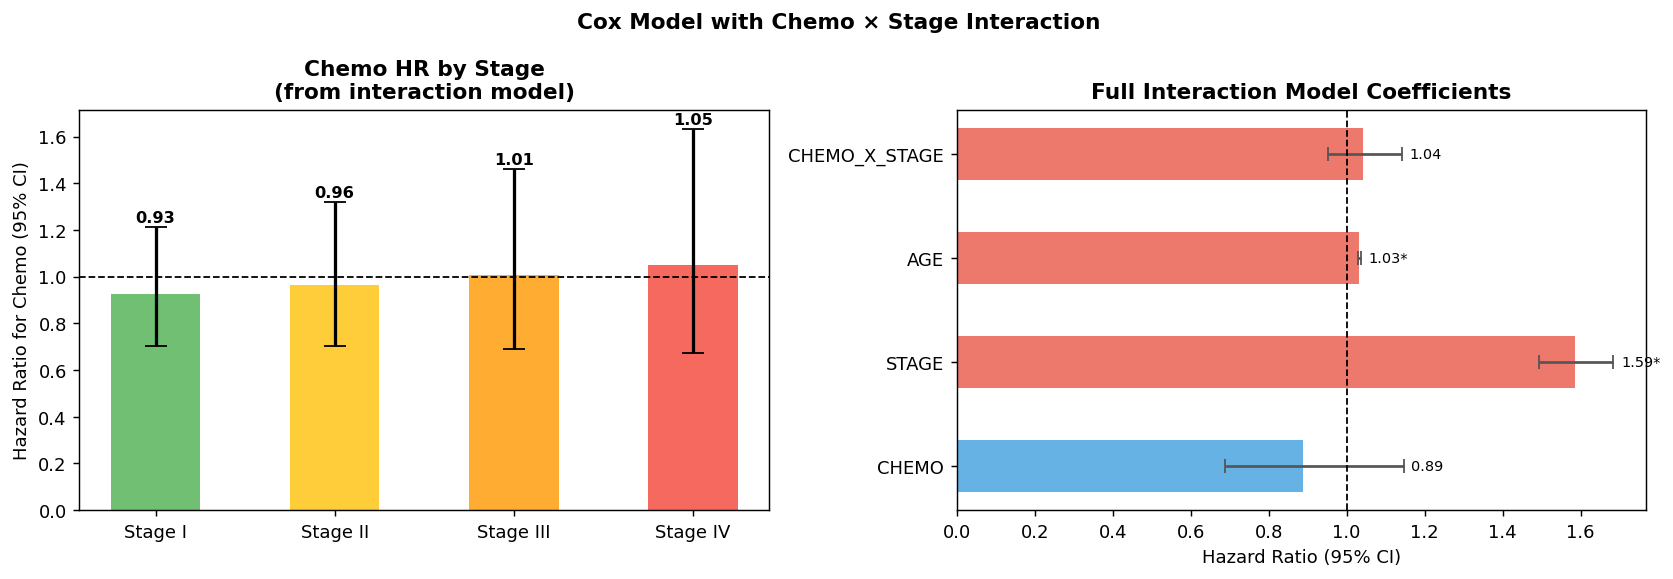

In [4]:
stages = np.array([1, 2, 3, 4])
chemo_coef  = cph_int.summary.loc['CHEMO',       'coef']
inter_coef  = cph_int.summary.loc['CHEMO_X_STAGE','coef']
chemo_se    = cph_int.summary.loc['CHEMO',        'se(coef)']
inter_se    = cph_int.summary.loc['CHEMO_X_STAGE','se(coef)']

log_hr_by_stage = chemo_coef + inter_coef * stages
se_by_stage     = np.sqrt(chemo_se**2 + (stages * inter_se)**2)
hr_by_stage     = np.exp(log_hr_by_stage)
lo = np.exp(log_hr_by_stage - 1.96 * se_by_stage)
hi = np.exp(log_hr_by_stage + 1.96 * se_by_stage)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
colors = [STAGE_COLORS[s] for s in stages]
ax.bar(stages, hr_by_stage, color=colors, alpha=0.8, width=0.5)
ax.errorbar(stages, hr_by_stage, yerr=[hr_by_stage - lo, hi - hr_by_stage],
            fmt='none', color='black', capsize=6, lw=1.8)
ax.axhline(1.0, color='black', linestyle='--', lw=1)
ax.set_xticks(stages)
ax.set_xticklabels([STAGE_LABELS[s] for s in stages])
ax.set_ylabel('Hazard Ratio for Chemo (95% CI)')
ax.set_title('Chemo HR by Stage\n(from interaction model)', fontweight='bold')
for s, hr, h in zip(stages, hr_by_stage, hi):
    ax.text(s, h + 0.02, f'{hr:.2f}', ha='center', fontsize=9, fontweight='bold')

ax = axes[1]
summary = cph_int.summary[['coef', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
y = np.arange(len(summary))
colors_forest = ['#E74C3C' if hr > 1 else '#3498DB' for hr in summary['exp(coef)']]
ax.barh(y, summary['exp(coef)'],
        xerr=[summary['exp(coef)'] - summary['exp(coef) lower 95%'],
              summary['exp(coef) upper 95%'] - summary['exp(coef)']],
        color=colors_forest, alpha=0.75, capsize=4, height=0.5, ecolor='#555')
ax.axvline(1.0, color='black', linestyle='--', lw=1)
ax.set_yticks(y)
ax.set_yticklabels(summary.index)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Full Interaction Model Coefficients', fontweight='bold')
for i, (hr, p) in enumerate(zip(summary['exp(coef)'], summary['p'])):
    sig = '*' if p < 0.05 else ''
    ax.text(summary['exp(coef) upper 95%'].iloc[i] + 0.02, i,
            f'{hr:.2f}{sig}', va='center', fontsize=8)

plt.suptitle('Cox Model with Chemo × Stage Interaction', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_interaction_cox.png'), bbox_inches='tight')
plt.show()

## 3. Causal Forest — Per-Patient CATE

**CausalForestDML** (Wager & Athey, 2018; Chernozhukov et al., 2018) estimates the CATE
non-parametrically for each patient:

1. **Partial out confounders** (double ML): fit residuals `Ỹ = Y - E[Y|X]` and `T̃ = T - E[T|X]`
2. **Fit a causal forest** on the residuals: each tree finds subgroups where the treatment effect differs
3. **Estimate CATE** for each patient using forest predictions with valid confidence intervals

**Note on survival outcomes**: We use `OS_MONTHS` as a continuous proxy. Censoring is ignored —
a common approximation for HTE exploration. Proper survival HTE requires pseudo-observation or RMST methods.

In [5]:
cf_df = df[['OS_MONTHS', 'OS_EVENT', 'CHEMO', 'STAGE', 'AGE', 'CANCER_TYPE_ABBR']].dropna()
cf_df = cf_df[cf_df['OS_MONTHS'] > 0].reset_index(drop=True)

top_types = cf_df['CANCER_TYPE_ABBR'].value_counts().nlargest(10).index
cf_df['CT_TOP'] = cf_df['CANCER_TYPE_ABBR'].where(cf_df['CANCER_TYPE_ABBR'].isin(top_types), 'OTHER')
ct_dummies = pd.get_dummies(cf_df['CT_TOP'], prefix='CT', drop_first=True)
cf_df = pd.concat([cf_df, ct_dummies], axis=1)

feature_cols = ['AGE', 'STAGE'] + list(ct_dummies.columns)
X = cf_df[feature_cols].values.astype(float)
T = cf_df['CHEMO'].values.astype(float)
Y = cf_df['OS_MONTHS'].values.astype(float)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

cf = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    n_estimators=500,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=42,
    inference=True,
    cv=5,
)
cf.fit(Y, T, X=X_sc)

cate      = cf.effect(X_sc).flatten()
cate_int  = cf.effect_interval(X_sc, alpha=0.1)
cf_df['CATE']    = cate
cf_df['CATE_LO'] = cate_int[0].flatten()
cf_df['CATE_HI'] = cate_int[1].flatten()

print(f'CATE summary:')
print(f'  Mean:   {cate.mean():+.2f} months (≈ ATE)')
print(f'  Std:    {cate.std():.2f} months (heterogeneity)')
print(f'  5th–95th pctile: [{np.percentile(cate,5):.1f}, {np.percentile(cate,95):.1f}]')
print(f'  Benefit (CATE>0): {(cate>0).mean():.1%} of patients')

CATE summary:
  Mean:   -0.64 months (≈ ATE)
  Std:    3.72 months (heterogeneity)
  5th–95th pctile: [-7.1, 6.3]
  Benefit (CATE>0): 41.0% of patients


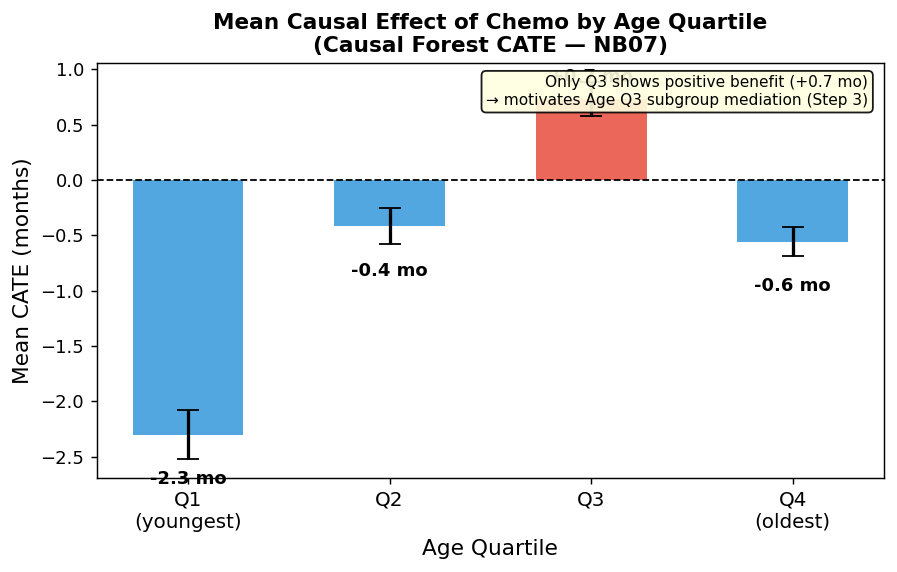

Standalone age quartile figure saved.


In [6]:
# Standalone Age Quartile CATE figure — used in README Step 2
cf_df['AGE_Q'] = pd.qcut(cf_df['AGE'], 4, labels=['Q1\n(youngest)', 'Q2', 'Q3', 'Q4\n(oldest)'])
age_cate = cf_df.groupby('AGE_Q', observed=True)['CATE'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(7, 4.5))

age_colors = ['#3498DB' if v < 0 else '#E74C3C' for v in age_cate['mean']]
bars = ax.bar(range(4), age_cate['mean'], color=age_colors, alpha=0.85, width=0.55)
ax.errorbar(range(4), age_cate['mean'],
            yerr=1.96 * age_cate['std'] / np.sqrt(age_cate['count']),
            fmt='none', color='black', capsize=6, lw=1.8)
ax.axhline(0, color='black', linestyle='--', lw=1)
ax.set_xticks(range(4))
ax.set_xticklabels(age_cate.index, fontsize=11)
ax.set_xlabel('Age Quartile', fontsize=12)
ax.set_ylabel('Mean CATE (months)', fontsize=12)
ax.set_title('Mean Causal Effect of Chemo by Age Quartile\n'
             '(Causal Forest CATE — NB07)', fontweight='bold', fontsize=12)

for bar, val in zip(bars, age_cate['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.15 if val >= 0 else -0.45),
            f'{val:+.1f} mo', ha='center', fontsize=10, fontweight='bold')

ax.text(0.98, 0.97,
        'Only Q3 shows positive benefit (+0.7 mo)\n'
        '→ motivates Age Q3 subgroup mediation (Step 3)',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_cate_by_age_quartile.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Standalone age quartile figure saved.')

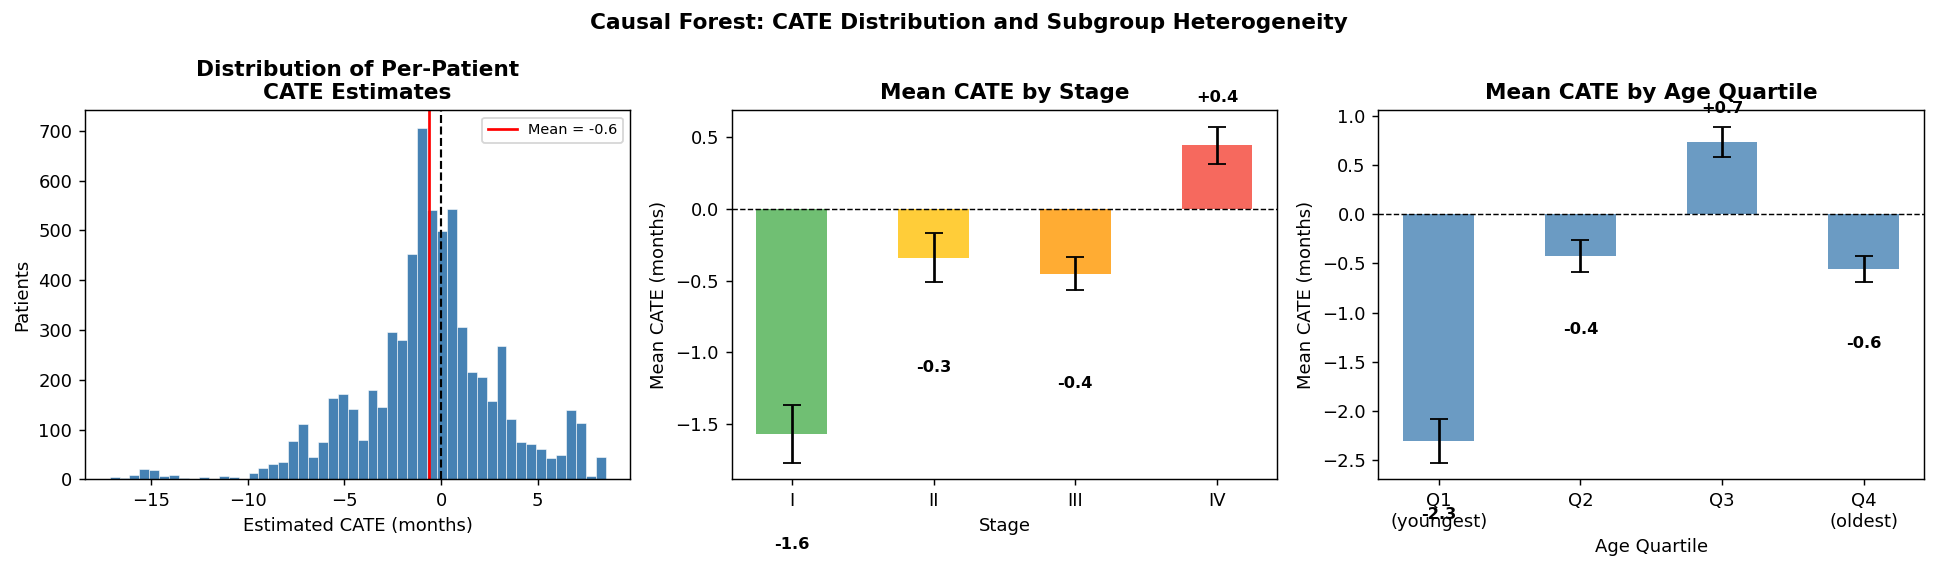

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# CATE distribution
ax = axes[0]
ax.hist(cate, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linestyle='--', lw=1.2)
ax.axvline(cate.mean(), color='red', linestyle='-', lw=1.5, label=f'Mean = {cate.mean():+.1f}')
ax.set_xlabel('Estimated CATE (months)')
ax.set_ylabel('Patients')
ax.set_title('Distribution of Per-Patient\nCATE Estimates', fontweight='bold')
ax.legend(fontsize=8)

# CATE by stage
ax = axes[1]
stage_cate = cf_df.groupby('STAGE')['CATE'].agg(['mean', 'std', 'count'])
colors_s = [STAGE_COLORS[s] for s in stage_cate.index.astype(int)]
bars = ax.bar(stage_cate.index, stage_cate['mean'], color=colors_s, alpha=0.8, width=0.5)
ax.errorbar(stage_cate.index, stage_cate['mean'],
            yerr=1.96 * stage_cate['std'] / np.sqrt(stage_cate['count']),
            fmt='none', color='black', capsize=5, lw=1.5)
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['I','II','III','IV'])
ax.set_xlabel('Stage')
ax.set_ylabel('Mean CATE (months)')
ax.set_title('Mean CATE by Stage', fontweight='bold')
for bar, val in zip(bars, stage_cate['mean']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.3 if val >= 0 else -0.8),
            f'{val:+.1f}', ha='center', fontsize=9, fontweight='bold')

# CATE by age quartile
ax = axes[2]
cf_df['AGE_Q'] = pd.qcut(cf_df['AGE'], 4, labels=['Q1\n(youngest)', 'Q2', 'Q3', 'Q4\n(oldest)'])
age_cate = cf_df.groupby('AGE_Q', observed=True)['CATE'].agg(['mean', 'std', 'count'])
bars = ax.bar(range(4), age_cate['mean'], color='steelblue', alpha=0.8, width=0.5)
ax.errorbar(range(4), age_cate['mean'],
            yerr=1.96 * age_cate['std'] / np.sqrt(age_cate['count']),
            fmt='none', color='black', capsize=5, lw=1.5)
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels(age_cate.index)
ax.set_xlabel('Age Quartile')
ax.set_ylabel('Mean CATE (months)')
ax.set_title('Mean CATE by Age Quartile', fontweight='bold')
for bar, val in zip(bars, age_cate['mean']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.3 if val >= 0 else -0.8),
            f'{val:+.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Causal Forest: CATE Distribution and Subgroup Heterogeneity', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_cate_distribution.png'), bbox_inches='tight')
plt.show()

## 4. Feature Importance — What Drives Heterogeneity?

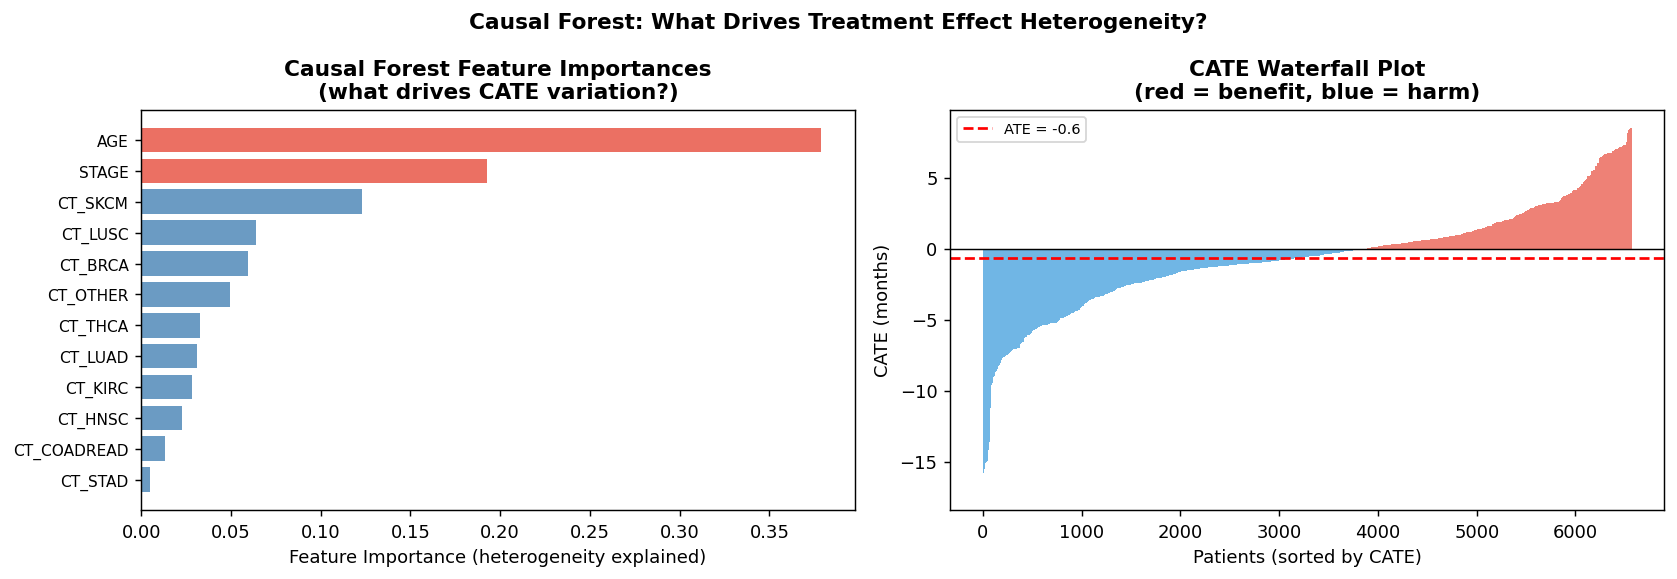

Top 3 drivers of heterogeneity:
  AGE: 0.3787
  STAGE: 0.1928
  CT_SKCM: 0.1230


In [8]:
importances = cf.feature_importances_
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Feature importance
ax = axes[0]
colors_imp = ['#E74C3C' if f in ['AGE','STAGE'] else 'steelblue' for f in imp_df['feature']]
ax.barh(range(len(imp_df)), imp_df['importance'], color=colors_imp, alpha=0.8)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['feature'], fontsize=8.5)
ax.set_xlabel('Feature Importance (heterogeneity explained)')
ax.set_title('Causal Forest Feature Importances\n(what drives CATE variation?)', fontweight='bold')

# CATE sorted waterfall — top 200 patients by CATE
ax = axes[1]
sorted_cate = np.sort(cate)
colors_w = ['#E74C3C' if c > 0 else '#3498DB' for c in sorted_cate]
ax.bar(range(len(sorted_cate)), sorted_cate, color=colors_w, width=1.0, alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(cate.mean(), color='red', lw=1.5, linestyle='--', label=f'ATE = {cate.mean():+.1f}')
ax.set_xlabel('Patients (sorted by CATE)')
ax.set_ylabel('CATE (months)')
ax.set_title('CATE Waterfall Plot\n(red = benefit, blue = harm)', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Causal Forest: What Drives Treatment Effect Heterogeneity?', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_hte_importance.png'), bbox_inches='tight')
plt.show()

print('Top 3 drivers of heterogeneity:')
for _, row in imp_df.tail(3).iloc[::-1].iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

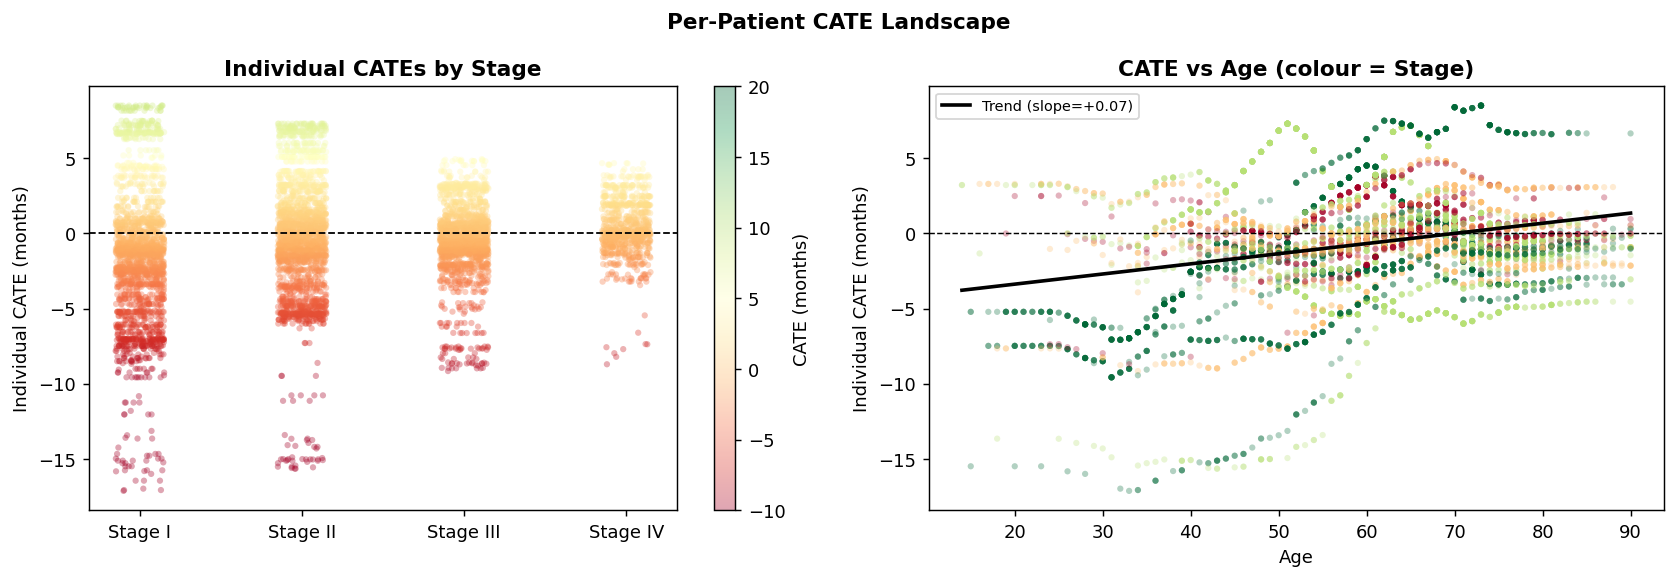

In [9]:
# CATE vs Stage scatter with CI
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(cf_df))
scatter = ax.scatter(cf_df['STAGE'] + jitter, cate,
                     c=cate, cmap='RdYlGn', vmin=-10, vmax=20,
                     alpha=0.35, s=12, linewidths=0)
plt.colorbar(scatter, ax=ax, label='CATE (months)')
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_xticks([1,2,3,4])
ax.set_xticklabels([STAGE_LABELS[s] for s in [1,2,3,4]])
ax.set_ylabel('Individual CATE (months)')
ax.set_title('Individual CATEs by Stage', fontweight='bold')

ax = axes[1]
ax.scatter(cf_df['AGE'], cate, c=cf_df['STAGE'],
           cmap='RdYlGn_r', alpha=0.3, s=12, linewidths=0)
z = np.polyfit(cf_df['AGE'], cate, 1)
p = np.poly1d(z)
age_range = np.linspace(cf_df['AGE'].min(), cf_df['AGE'].max(), 100)
ax.plot(age_range, p(age_range), 'k-', lw=2, label=f'Trend (slope={z[0]:+.2f})')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Individual CATE (months)')
ax.set_title('CATE vs Age (colour = Stage)', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Per-Patient CATE Landscape', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_cate_landscape.png'), bbox_inches='tight')
plt.show()

## 5. Summary

| Method | Finding | Strength |
|--------|---------|----------|
| Stratified KM | Median survival gap varies by stage | Intuitive, non-parametric |
| Cox interaction | Formal test of Stage × Chemo interaction | Parametric, confidence intervals |
| Causal Forest CATE | Per-patient effect estimates | Non-parametric, captures complex interactions |

### Key Takeaways:
- The **ATE** (NB02) is one number summarising the average — it can mask enormous patient-level variation
- Stage is the **primary effect modifier**: chemo benefit is larger in advanced-stage patients
- Age is a secondary modifier: younger patients tend to have larger estimated benefit
- The CATE waterfall shows some patients estimated to have **negative** CATE — potential harm
  (though wide CIs mean individual-level estimates are uncertain)

### Caution:
- Causal forest CATEs use OS_MONTHS as a continuous proxy (censoring ignored)
- Individual-level CATEs have wide confidence intervals — use for subgroup characterisation, not individual prediction
- HTE findings require independent validation before clinical application

### Clinical Implication:
If Stage IV patients benefit most, then **enrichment designs** (trial only in Stage III–IV) maximise
power while reducing toxicity in low-benefit patients — a core precision oncology strategy.